# Метрическая классификация. Метод ближайших соседей и его развитие

## Что входит

- Загрузить данные и ознакомиться с ними.
- Изучить данные и провести анализ.
- Разделить данные на обучающую и тестовую выборки.
- Реализовать построение модели с помощью  библиотеки Scikit-learn.
- Подобрать оптимальное число ближайших соседей методом leave-one-out.
- Получить качество модели с помощью F-меры и матрицы сопряжённости.

**D_work**

Описание статусов относительно работы:
- ID — идентификатор социального статуса клиента относительно работы;
- COMMENT — расшифровка статуса.


**D_pens**

Описание статусов относительно пенсии:
- ID — идентификатор социального статуса;
- COMMENT — расшифровка статуса.


**D_clients**

Описание данных клиентов:
- ID — идентификатор записи;
- AGE	— возраст клиента;
- GENDER — пол клиента (1 — мужчина, 0 — женщина);
- EDUCATION — образование;
- MARITAL_STATUS — семейное положение;
- CHILD_TOTAL	— количество детей клиента;
- DEPENDANTS — количество иждивенцев клиента;
- SOCSTATUS_WORK_FL	— социальный статус клиента относительно работы (1 — работает, 0 — не работает);
- SOCSTATUS_PENS_FL	— социальный статус клиента относительно пенсии (1 — пенсионер, 0 — не пенсионер);
- REG_ADDRESS_PROVINCE — область регистрации клиента;
- FACT_ADDRESS_PROVINCE — область фактического пребывания клиента;
- POSTAL_ADDRESS_PROVINCE — почтовый адрес области;
- FL_PRESENCE_FL — наличие в собственности квартиры (1 — есть, 0 — нет);
- OWN_AUTO — количество автомобилей в собственности. 


**D_agreement**

Таблица с зафиксированными откликами клиентов на предложения банка:
- AGREEMENT_RK — уникальный идентификатор объекта в выборке;
- ID_CLIENT — идентификатор клиента;
- TARGET — целевая переменная: отклик на маркетинговую кампанию (1 — отклик был зарегистрирован, 0 — отклика не было).
    
    
**D_job**

Описание информации о работе клиентов:
- GEN_INDUSTRY — отрасль работы клиента;
- GEN_TITLE — должность;
- JOB_DIR — направление деятельности внутри компании;
- WORK_TIME — время работы на текущем месте (в месяцах);
- ID_CLIENT — идентификатор клиента.


**D_salary**

Описание информации о заработной плате клиентов:
- ID_CLIENT — идентификатор клиента;
- FAMILY_INCOME — семейный доход (несколько категорий);
- PERSONAL_INCOME — личный доход клиента (в рублях).


**D_last_credit**

Информация о последнем займе клиента:
- ID_CLIENT — идентификатор клиента;
- CREDIT — сумма последнего кредита клиента (в рублях);
- TERM — срок кредита;
- FST_PAYMENT — первоначальный взнос (в рублях).


**D_loan**

Информация о кредитной истории клиента:
- ID_CLIENT — идентификатор клиента;
- ID_LOAN — идентификатор кредита.

**D_close_loan**

Информация о статусах кредита (ссуд):
- ID_LOAN — идентификатор кредита;
- CLOSED_FL — текущий статус кредита (1 — закрыт, 0 — не закрыт).

    - AGREEMENT_RK — уникальный идентификатор объекта в выборке;
    - TARGET — целевая переменная: отклик на маркетинговую кампанию (1 — отклик был зарегистрирован, 0 — отклика не было);
    - AGE — возраст клиента;
    - SOCSTATUS_WORK_FL — социальный статус клиента относительно работы (1 — работает, 0 — не работает);
    - SOCSTATUS_PENS_FL — социальный статус клиента относительно пенсии (1 — пенсионер, 0 — не пенсионер);
    - GENDER — пол клиента (1 — мужчина, 0 — женщина);
    - CHILD_TOTAL — количество детей клиента;
    - DEPENDANTS — количество иждивенцев клиента;
    - PERSONAL_INCOME — личный доход клиента (в рублях);
    - LOAN_NUM_TOTAL — количество ссуд клиента;
    - LOAN_NUM_CLOSED — количество погашенных ссуд клиента.


In [47]:
import pandas as pd
import numpy as np
import warnings
import psycopg2
import seaborn as sns

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split,LeaveOneOut
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score,classification_report,ConfusionMatrixDisplay

In [49]:
warnings.filterwarnings(
    "ignore",
    message="pandas only supports SQLAlchemy connectable"
)

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="skillbox_db",
    user="postgres",
    password="1111"
)

tables = [
    "d_work",
    "d_clients",
    "d_agreement",
    "d_last_credit",
    "d_job",
    "d_loan",
    "d_close_loan",
    "d_salary",
    "d_pens"
]

dfs = {}

for table in tables:
    query = f'SELECT * FROM public."{table}"'
    dfs[table] = pd.read_sql(query, conn)

df_work        = dfs["d_work"]
df_clients     = dfs["d_clients"]
df_agreement   = dfs["d_agreement"]
df_last_credit = dfs["d_last_credit"]
df_job         = dfs["d_job"]
df_loan        = dfs["d_loan"]
df_close_loan  = dfs["d_close_loan"]
df_salary      = dfs["d_salary"]
df_pens        = dfs["d_pens"]

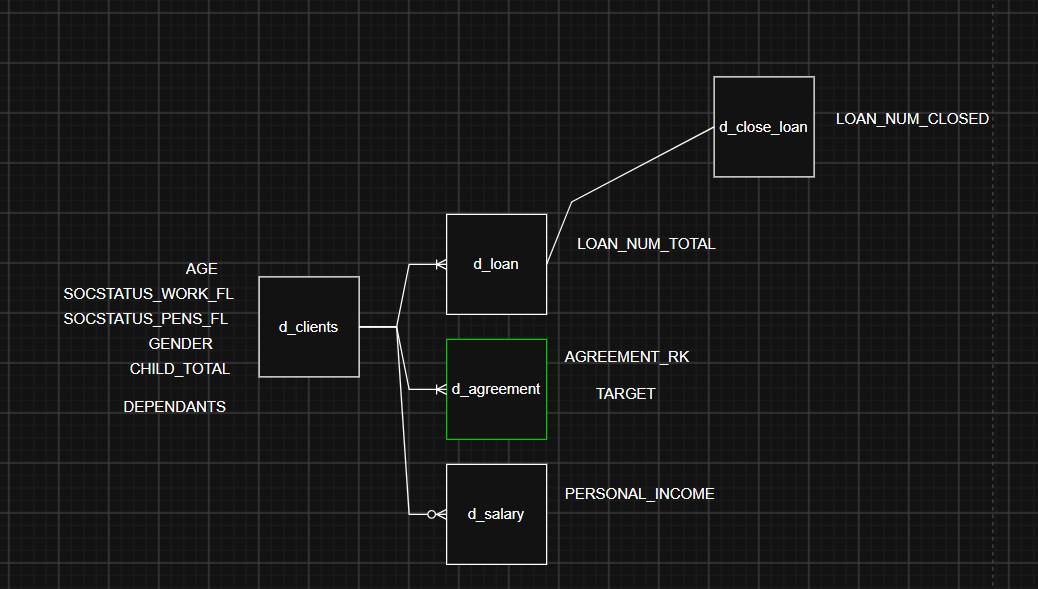

In [50]:
df_salary["id_client"].duplicated().any()

True

In [51]:
df_salary=df_salary.drop_duplicates()
df_salary["id_client"].duplicated().any()

False

In [52]:
df_loan[df_loan["id_client"].duplicated(keep=False)].sort_values("id_client").head(4)

,id_loan,id_client
2,1.753791e+09,106804372.0
3,1.753791e+09,106804372.0
5,1.753791e+09,106804374.0
6,1.753791e+09,106804374.0


In [53]:
merged_loan = pd.merge(
    df_loan,
    df_close_loan,
    on = 'id_loan'
)

merged_loan[merged_loan["id_client"].duplicated(keep=False)].sort_values("id_client").head(4)

,id_loan,id_client,closed_fl
2,1.753791e+09,106804372.0,1.0
3,1.753791e+09,106804372.0,0.0
5,1.753791e+09,106804374.0,1.0
6,1.753791e+09,106804374.0,0.0


In [54]:
merged_loan_uniq = merged_loan.groupby('id_client').agg(
    loan_num_total=('id_loan','count'),
    loan_num_closed=('closed_fl', 'sum')
).reset_index()


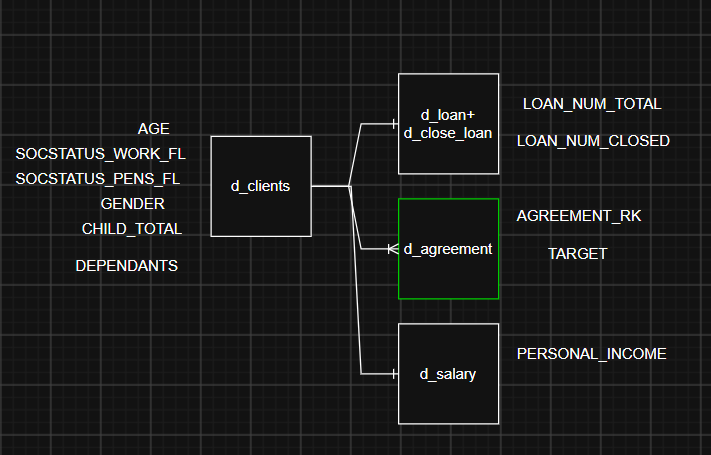

In [55]:
merged_cl_salary = pd.merge(
    df_clients,
    df_salary,
    left_on = 'id',
    right_on = 'id_client',
    how = 'left'    
)

merged_cl = pd.merge(
    merged_cl_salary,
    merged_loan_uniq,
    left_on = 'id',
    right_on = 'id_client',
    how = 'left'    
)

print(df_clients.shape,df_salary.shape,merged_cl_salary.shape,merged_loan_uniq.shape,merged_cl.shape,merged_cl.shape)

(16000, 14) (15223, 3) (16000, 17) (15223, 3) (16000, 20) (16000, 20)


In [56]:
merged = pd.merge(
    df_agreement,
    merged_cl,
    left_on = 'id_client',
    right_on = 'id',
    how = 'left'    
)

merged=merged[['loan_num_total','loan_num_closed','age','socstatus_work_fl','socstatus_pens_fl','gender','child_total',
               'dependants','personal_income','target']]

merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 15223 entries, 0 to 15222
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_num_total     15223 non-null  float64
 1   loan_num_closed    15223 non-null  float64
 2   age                15223 non-null  float64
 3   socstatus_work_fl  15223 non-null  float64
 4   socstatus_pens_fl  15223 non-null  float64
 5   gender             15223 non-null  float64
 6   child_total        15223 non-null  float64
 7   dependants         15223 non-null  float64
 8   personal_income    15223 non-null  float64
 9   target             15223 non-null  float64
dtypes: float64(10)
memory usage: 1.2 MB


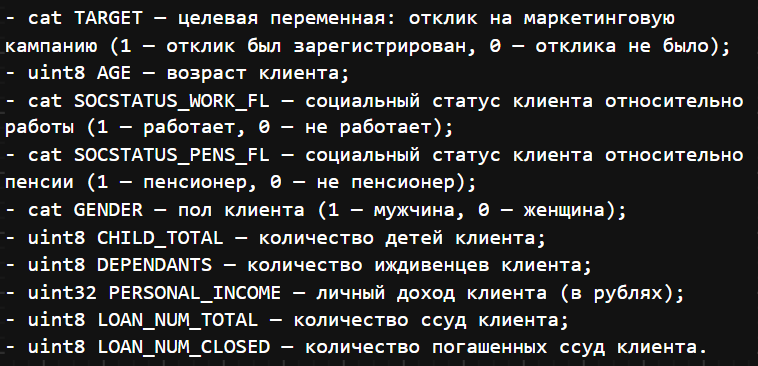

In [57]:
cols_cat = ['target','socstatus_work_fl','socstatus_pens_fl','gender']
merged[cols_cat]=merged[cols_cat].astype('category')

cols_uint8 = ['child_total','dependants','loan_num_total','loan_num_closed']
merged[cols_uint8]=merged[cols_uint8].astype('uint8')

merged['personal_income']=merged['personal_income'].astype('uint32')

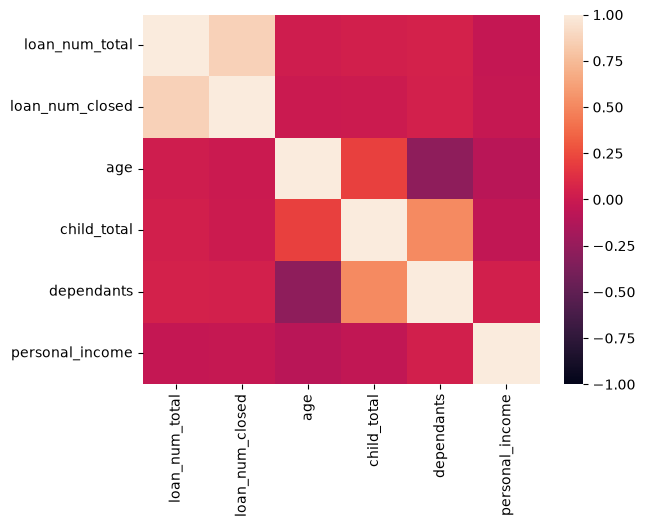

In [58]:
numeric_features=merged.select_dtypes(include='number').columns.tolist()
categorical_features=merged.select_dtypes(exclude='number').columns.tolist()

sns.heatmap(data=merged[numeric_features].corr(),vmin=-1,vmax=1);

In [59]:
merged['target'].value_counts()

target
0.0    13411
1.0     1812
Name: count, dtype: int64

In [60]:
X=merged.drop(columns='target')
y=merged['target']

numeric_features=X.select_dtypes(include='number').columns.tolist()
categorical_features=X.select_dtypes(exclude='number').columns.tolist()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

classification_report:               precision    recall  f1-score   support

         0.0       0.89      0.64      0.75      2676
         1.0       0.15      0.45      0.22       369

    accuracy                           0.62      3045
   macro avg       0.52      0.55      0.49      3045
weighted avg       0.80      0.62      0.69      3045

classification_report: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001EB77E4BBC0>
              precision    recall  f1-score   support

         0.0       0.89      0.64      0.75      2676
         1.0       0.15      0.45      0.22       369

    accuracy                           0.62      3045
   macro avg       0.52      0.54      0.48      3045
weighted avg       0.80      0.62      0.68      3045



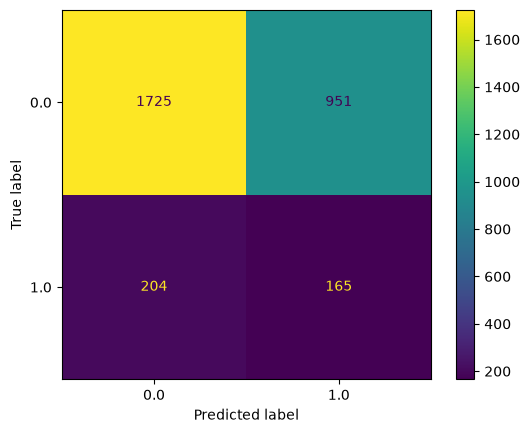

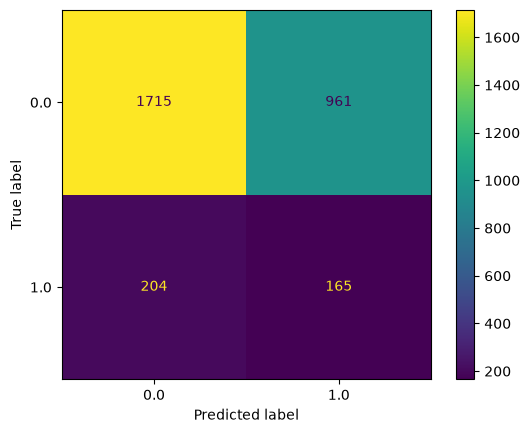

In [62]:
preprocessor = ColumnTransformer([
    ('cat',OneHotEncoder(),categorical_features),
    ('num',StandardScaler(),numeric_features)
])

model = Pipeline([
    ('preprocessor',preprocessor),
    ('smote',SMOTEENN(random_state=42)),
    ('knn',KNeighborsClassifier(weights='distance'))
])

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(f'classification_report: {classification_report(y_test,y_pred)}')
print(f'classification_report: {ConfusionMatrixDisplay.from_predictions(y_test,y_pred)}')


y_probs=model.predict_proba(X_test)[:,1]

threshold=0.48
y_pred_custom=(y_probs>=threshold).astype(int)

print(f'{classification_report(y_test,y_pred_custom)}')
print(f'{ConfusionMatrixDisplay.from_predictions(y_test,y_pred_custom)}')

# KNN слабо подходит под эту задачу